# Import data

In [133]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)        # To avoid linebreaks
pd.set_option('display.max_rows', None)

# Visit https://www.tennisabstract.com/charting/20120129-M-Australian_Open-F-Novak_Djokovic-Rafael_Nadal.html
#     for insteresting stats
match_id = "20120129-M-Australian_Open-F-Novak_Djokovic-Rafael_Nadal"

dfAll = pd.read_csv("./data/charting-m-points-2010s.csv")

dfRally = dfAll[dfAll["match_id"] == match_id].copy()
dfRally = dfRally.rename(columns={"Pt": "PointNumber"})
dfRally = dfRally.sort_values("PointNumber").set_index("PointNumber")


dfRally["Gm2"] = dfRally["Gm2"].astype(int)

dfRally.head()

,match_id,Set1,Set2,Gm1,Gm2,Pts,Gm#,TbSet,Svr,1st,2nd,Notes,PtWinner
PointNumber,,,,,,,,,,,,,
1,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,0-0,1,True,1,6w,4b27b3f3f1b2f3f1d@,NaN,1
2,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-0,1,True,1,6w,4f27b3n@,NaN,2
3,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-15,1,True,1,6w,4b28f3f3b3f3b3f2f3f1f1b2f1n@,NaN,2
4,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-30,1,True,1,6b28f3*,NaN,NaN,1
5,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,30-30,1,True,1,4w,5b39b1b3b3f1f2f2d@,NaN,1


In [134]:
match_id_gs = "2012-ausopen-1701"

dfGSAll = pd.read_csv("./data/tennisSlamPointByPoint/2012-ausopen-points.csv")

dfGS = dfGSAll[dfGSAll["match_id"] == match_id_gs].copy()
dfGS = dfGS.sort_values("PointNumber").set_index("PointNumber")
#dfGS.index = range(1, len(dfGS) + 1)

dfGS.head()

,match_id,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointWinner,PointServer,Speed_KMH,Rally,P1Score,P2Score,P1Momentum,P2Momentum,P1PointsWon,P2PointsWon,P1Ace,P2Ace,P1Winner,P2Winner,P1DoubleFault,P2DoubleFault,P1UnfErr,P2UnfErr,P1NetPoint,P2NetPoint,P1NetPointWon,P2NetPointWon,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,P1FirstSrvIn,P2FirstSrvIn,P1FirstSrvWon,P2FirstSrvWon,P1SecondSrvIn,P2SecondSrvIn,P1SecondSrvWon,P2SecondSrvWon,P1ForcedError,P2ForcedError,History,Speed_MPH,P1BreakPointMissed,P2BreakPointMissed,ServeIndicator,Serve_Direction,Winner_FH,Winner_BH,ServingTo,P1TurningPoint,P2TurningPoint
PointNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2012-ausopen-1701,0:00:00,1,0,0,0,1,0,1,1,182,NaN,15,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21020,113,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-ausopen-1701,0:00:36,1,0,0,0,1,0,2,1,142,NaN,15,15,1,2,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12020,88,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-ausopen-1701,0:01:18,1,0,0,0,1,0,2,1,0,NaN,15,30,1,3,1,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11020,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-ausopen-1701,0:02:21,1,0,0,0,1,0,1,1,201,NaN,30,30,4,3,2,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11010,124,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-ausopen-1701,0:02:51,1,0,0,0,1,0,1,1,150,NaN,40,30,5,1,3,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21020,93,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
print(len(dfGS) == len(dfRally))
print(dfRally.index.equals(dfGS.index))

True
True


In [136]:
dfGS_noid = dfGS.drop(columns=["match_id"], errors="ignore")

df = dfRally.join(
    dfGS_noid,
    how="inner",
    # lsuffix="_rally", # rsuffix="_gs"
)

assert len(df) == len(dfRally) == len(dfGS)
assert df.index.name == "PointNumber"
print(df["match_id"].nunique())

df.head()


1


,match_id,Set1,Set2,Gm1,Gm2,Pts,Gm#,TbSet,Svr,1st,2nd,Notes,PtWinner,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointWinner,PointServer,Speed_KMH,Rally,P1Score,P2Score,P1Momentum,P2Momentum,P1PointsWon,P2PointsWon,P1Ace,P2Ace,P1Winner,P2Winner,P1DoubleFault,P2DoubleFault,P1UnfErr,P2UnfErr,P1NetPoint,P2NetPoint,P1NetPointWon,P2NetPointWon,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,P1FirstSrvIn,P2FirstSrvIn,P1FirstSrvWon,P2FirstSrvWon,P1SecondSrvIn,P2SecondSrvIn,P1SecondSrvWon,P2SecondSrvWon,P1ForcedError,P2ForcedError,History,Speed_MPH,P1BreakPointMissed,P2BreakPointMissed,ServeIndicator,Serve_Direction,Winner_FH,Winner_BH,ServingTo,P1TurningPoint,P2TurningPoint
PointNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,0-0,1,True,1,6w,4b27b3f3f1b2f3f1d@,NaN,1,0:00:00,1,0,0,0,1,0,1,1,182,NaN,15,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21020,113,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
2,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-0,1,True,1,6w,4f27b3n@,NaN,2,0:00:36,1,0,0,0,1,0,2,1,142,NaN,15,15,1,2,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12020,88,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
3,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-15,1,True,1,6w,4b28f3f3b3f3b3f2f3f1f1b2f1n@,NaN,2,0:01:18,1,0,0,0,1,0,2,1,0,NaN,15,30,1,3,1,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11020,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
4,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-30,1,True,1,6b28f3*,NaN,NaN,1,0:02:21,1,0,0,0,1,0,1,1,201,NaN,30,30,4,3,2,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11010,124,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN
5,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,30-30,1,True,1,4w,5b39b1b3b3f1f2f2d@,NaN,1,0:02:51,1,0,0,0,1,0,1,1,150,NaN,40,30,5,1,3,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21020,93,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN


# Data preparation

## Separate rally from serve

In [137]:
players = {
    1: "Novak Djokovic",   # server code 1
    2: "Rafael Nadal"
}
handed = {
    "Novak Djokovic": "R",
    "Rafael Nadal": "L"
}

SHOT_LETTERS = set("fbrsvzopuylmhijktq")

# Split each point into serve code and rally code
def SplitServeFromRally(row):
    sequence = row["2nd"] if isinstance(row["2nd"], str) and row["2nd"].strip() else row["1st"]
    # Handle missing data
    if not isinstance(sequence, str):
        return "", ""
    for idx, char in enumerate(sequence):
        if char.lower() in SHOT_LETTERS:
            return sequence[:idx], sequence[idx:]
    # No rally shot found -> serve-only point (ace, double fault, unreturnable, etc.)
    return sequence, ""
    
df[["serve", "rally"]] = df.apply(SplitServeFromRally, axis=1, result_type="expand")

df[['rally']].head()

,rally
PointNumber,
1,b27b3f3f1b2f3f1d@
2,f27b3n@
3,b28f3f3b3f3b3f2f3f1f1b2f1n@
4,b28f3*
5,b39b1b3b3f1f2f2d@


## Separate shots

In [138]:
POSITION_FLAGS = "+-^=;"  # approach, net, baseline smash, drop-volley, net-cord markers


def ParseToken(token: str, shotIndex: int) -> dict:
    shot = token[0].lower()
    rest = token[1:]

    positions = ""
    # Handle cases like b+;3 (approach + net-cord)
    while rest and rest[0] in POSITION_FLAGS:
        positions += rest[0]
        rest = rest[1:]
    positions = positions if positions else pd.NA

    direction = int(rest[0]) if rest and rest[0] in "0123" else None
    if direction is not None:
        rest = rest[1:]

    # --- DEPTH (ONLY FOR RETURNS THAT LAND IN) ---
    ## Return token grammar: [shot][positions][direction][depth][error_code][forced/unforced]
    depth = pd.NA
    if shotIndex == 0 and rest and rest[0] in "789":
        depth = int(rest[0])
        rest = rest[1:]

    error_code = rest[0] if rest and rest[0] in "nwdxge!" else None
    if error_code:
        rest = rest[1:]

    outcome = rest[0] if rest and rest[0] in "*@#" else None
    # outcome = None
    # for c in reversed(token):
    #     if c in "*@#":
    #         outcome = c
    #         break


    return {
        "stroke": shot,
        "positions": positions,   # e.g., "+", "-", etc.
        "direction": direction,   # 1/2/3 (0 or None if missing)
        "depth": depth,
        "errorCode": error_code,
        "outcome": outcome,
    }


# Tokens: each shot starts with a letter and consumes all characters until the next letter
TOKENS_REGEX = re.compile(r"[A-Za-z][^A-Za-z]*")

# Iterate through all points
shotRows = []

for pt, row in df.iterrows():
    rally = row["rally"]
    if not rally:
        continue  # ace, double fault, etc.

    tokens = TOKENS_REGEX.findall(rally)
    server = players[row["Svr"]]
    returner = players[1 if row["Svr"] == 2 else 2]

    for idx, token in enumerate(tokens):
        hitter = returner if idx % 2 == 0 else server
        parsed = ParseToken(token, idx)
        shotRows.append({
            "PointNumber": pt,
            "shotIndex": idx,
            "server": server,
            "hitter": hitter,
            **parsed
        })

shots = pd.DataFrame(shotRows)
shots['direction'] = shots['direction'].astype("Int64")

In [139]:
def AddDirectionLabel(direction, hitter):
    if direction is None:
        return "unknown"
    opponent = players[1] if hitter == players[2] else players[2]
    if handed[opponent] == "R":
        mapping = {1: "to opponent FH", 2: "middle", 3: "to opponent BH"}
    else:
        mapping = {1: "to opponent BH", 2: "middle", 3: "to opponent FH"}
    return mapping.get(direction, pd.NA)

shots["target_zone"] = shots.apply(
    lambda r: AddDirectionLabel(r["direction"], r["hitter"]),
    axis=1)


def AddGeometry(row):
    # Guard against missing direction (pd.NA, None, NaN)
    if pd.isna(row["direction"]):
        return "unknown"

    if row["stroke"] in ("f", "b", "r", "s"):
        if row["target_zone"] == "middle":
            return "middle"

        # Djokovic/Nadal-safe, handedness-independent logic
        return "crosscourt" if (
            (row["stroke"] == "f" and row["direction"] == 1) or
            (row["stroke"] == "b" and row["direction"] == 3)
        ) else "down_the_line"

    return "other"

shots["geometry"] = shots.apply(AddGeometry, axis=1)

## Add rally length & point ending type

In [140]:
# Point level feature -> add it to dfGS
rally_length = shots.groupby("PointNumber").size()

df["rally_length"] = rally_length
df["rally_length"] = df["rally_length"].fillna(0).astype(int)

def PointEndingType(row):
    # --- Serve-only outcomes (authoritative) ---
    if row["P1Ace"] == 1 or row["P2Ace"] == 1:
        return "serve_ace"

    if row["P1DoubleFault"] == 1 or row["P2DoubleFault"] == 1:
        return "double_fault"

    # --- Rally outcomes (authoritative) ---
    if row["P1Winner"] == 1 or row["P2Winner"] == 1:
        return "rally_winner"

    if row["P1UnfErr"] == 1 or row["P2UnfErr"] == 1:
        return "rally_unforced_error"

    if row["P1ForcedError"] == 1 or row["P2ForcedError"] == 1:
        return "rally_forced_error"

    # --- Pressure / induced errors (very common) ---
    if row["PointWinner"] == row["PointServer"]:
        return "server_induced_error"
    else:
        return "returner_induced_error"

df["point_end_type"] = df.apply(PointEndingType, axis=1)

df.head()


,match_id,Set1,Set2,Gm1,Gm2,Pts,Gm#,TbSet,Svr,1st,2nd,Notes,PtWinner,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointWinner,PointServer,Speed_KMH,Rally,P1Score,P2Score,P1Momentum,P2Momentum,P1PointsWon,P2PointsWon,P1Ace,P2Ace,P1Winner,P2Winner,P1DoubleFault,P2DoubleFault,P1UnfErr,P2UnfErr,P1NetPoint,P2NetPoint,P1NetPointWon,P2NetPointWon,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,P1FirstSrvIn,P2FirstSrvIn,P1FirstSrvWon,P2FirstSrvWon,P1SecondSrvIn,P2SecondSrvIn,P1SecondSrvWon,P2SecondSrvWon,P1ForcedError,P2ForcedError,History,Speed_MPH,P1BreakPointMissed,P2BreakPointMissed,ServeIndicator,Serve_Direction,Winner_FH,Winner_BH,ServingTo,P1TurningPoint,P2TurningPoint,serve,rally,rally_length,point_end_type
PointNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,0-0,1,True,1,6w,4b27b3f3f1b2f3f1d@,NaN,1,0:00:00,1,0,0,0,1,0,1,1,182,NaN,15,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21020,113,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,4,b27b3f3f1b2f3f1d@,8,rally_unforced_error
2,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-0,1,True,1,6w,4f27b3n@,NaN,2,0:00:36,1,0,0,0,1,0,2,1,142,NaN,15,15,1,2,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12020,88,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,4,f27b3n@,3,rally_unforced_error
3,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-15,1,True,1,6w,4b28f3f3b3f3b3f2f3f1f1b2f1n@,NaN,2,0:01:18,1,0,0,0,1,0,2,1,0,NaN,15,30,1,3,1,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11020,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,4,b28f3f3b3f3b3f2f3f1f1b2f1n@,13,rally_unforced_error
4,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,15-30,1,True,1,6b28f3*,NaN,NaN,1,0:02:21,1,0,0,0,1,0,1,1,201,NaN,30,30,4,3,2,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11010,124,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,6,b28f3*,2,rally_winner
5,20120129-M-Australian_Open-F-Novak_Djokovic-Ra...,0,0,0,0,30-30,1,True,1,4w,5b39b1b3b3f1f2f2d@,NaN,1,0:02:51,1,0,0,0,1,0,1,1,150,NaN,40,30,5,1,3,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21020,93,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,5,b39b1b3b3f1f2f2d@,8,rally_unforced_error


In [141]:
shots.head()

,PointNumber,shotIndex,server,hitter,stroke,positions,direction,depth,errorCode,outcome,target_zone,geometry
0,1,0,Novak Djokovic,Rafael Nadal,b,NaN,2,7,NaN,NaN,middle,middle
1,1,1,Novak Djokovic,Novak Djokovic,b,NaN,3,<NA>,NaN,NaN,to opponent FH,crosscourt
2,1,2,Novak Djokovic,Rafael Nadal,f,NaN,3,<NA>,NaN,NaN,to opponent BH,down_the_line
3,1,3,Novak Djokovic,Novak Djokovic,f,NaN,1,<NA>,NaN,NaN,to opponent BH,crosscourt
4,1,4,Novak Djokovic,Rafael Nadal,b,NaN,2,<NA>,NaN,NaN,middle,middle


# Basic statistics

## Rally length

In [142]:
df["rally_length"].describe()

count    369.000000
mean       5.512195
std        5.252896
min        0.000000
25%        2.000000
50%        4.000000
75%        8.000000
max       32.000000
Name: rally_length, dtype: float64

In [143]:
rally_by_end = (
    df
    .groupby("point_end_type")["rally_length"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
)

rally_by_end


,count,mean,median
point_end_type,,,
double_fault,6,0.000000,0.0
serve_ace,19,0.000000,0.0
server_induced_error,94,3.574468,2.0
rally_winner,82,6.500000,5.0
returner_induced_error,34,6.911765,5.0
rally_unforced_error,134,6.940299,5.0


## Rally length vs point winner

In [144]:

bins = [0, 1, 4, 8, 12, 20, 32]
labels = ["0", "1–4", "5–8", "9–12", "13–20", "20+"]

df["rally_bin"] = pd.cut(df["rally_length"], bins=bins, labels=labels)

(
    df
    .groupby("rally_bin")["PointWinner"]
    .value_counts(normalize=True)
    .unstack()
)

PointWinner,1,2
rally_bin,,
0,0.511111,0.488889
1–4,0.539130,0.460870
5–8,0.586207,0.413793
9–12,0.500000,0.500000
13–20,0.454545,0.545455
20+,0.500000,0.500000


## 5th set momentum

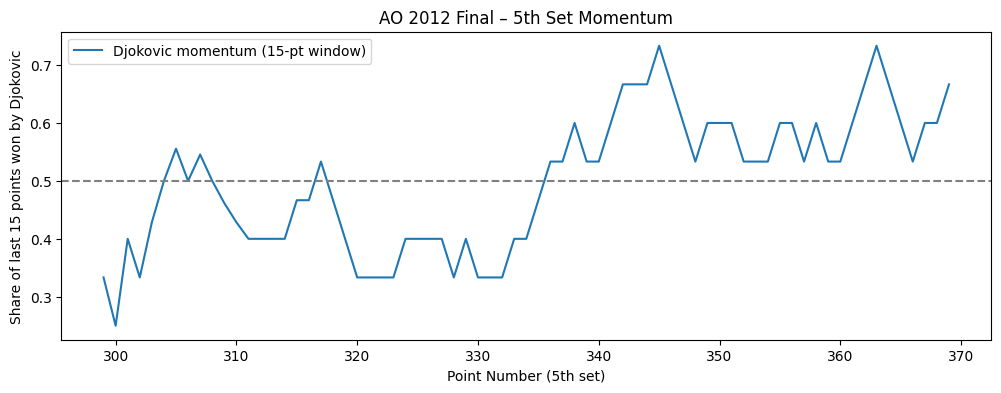

In [145]:
import matplotlib.pyplot as plt

ROLLING_WINDOW_SIZE = 15

df5 = df[df["SetNo"] == 5].copy()

df5["djokovic_point"] = (df5["PointWinner"] == 1).astype(int)


df5[f"momentum_{ROLLING_WINDOW_SIZE}"] = (
    df5["djokovic_point"]
    .rolling(window=15, min_periods=3)
    .mean()
)

plt.figure(figsize=(12, 4))
plt.plot(df5.index, df5[f"momentum_{ROLLING_WINDOW_SIZE}"], label=f"Djokovic momentum ({ROLLING_WINDOW_SIZE}‑pt window)")
plt.axhline(0.5, linestyle="--", color="gray")
plt.xlabel("Point Number (5th set)")
plt.ylabel(f"Share of last {ROLLING_WINDOW_SIZE} points won by Djokovic")
plt.title("AO 2012 Final – 5th Set Momentum")
plt.legend()
plt.show()

In [146]:
momentum_flips = df5[
    (df5[f"momentum_{ROLLING_WINDOW_SIZE}"].shift(1) <= 0.5) &
    (df5[f"momentum_{ROLLING_WINDOW_SIZE}"] > 0.5)
]

momentum_flips[
    ["GameNo", "PointWinner", 'Gm1', 'Gm2', 'Pts', "rally_length", "point_end_type"]
].head()


,GameNo,PointWinner,Gm1,Gm2,Pts,rally_length,point_end_type
PointNumber,,,,,,,
305,2,1,0,1,30-0,0,serve_ace
307,2,1,0,1,40-15,1,rally_unforced_error
317,4,1,1,2,40-30,7,server_induced_error
336,8,1,3,4,15-15,2,rally_unforced_error


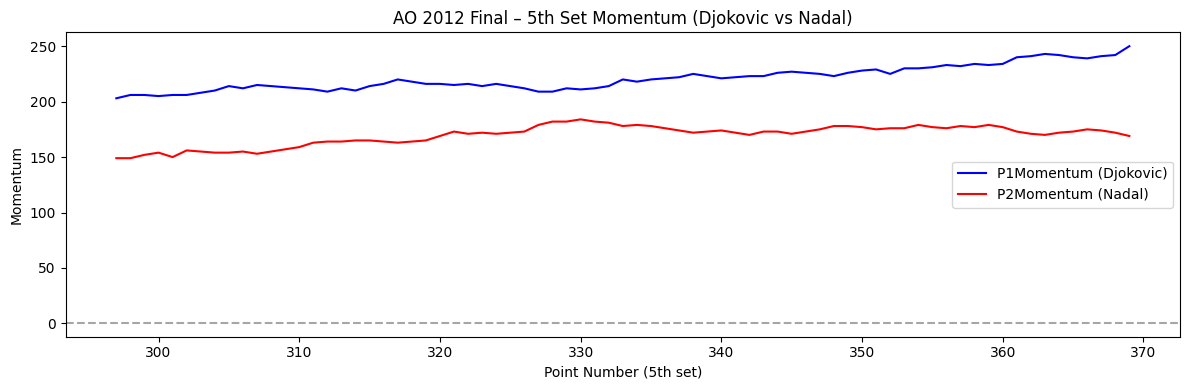

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(
    df5.index,
    df5["P1Momentum"],
    label="P1Momentum (Djokovic)",
    color="blue"
)

plt.plot(
    df5.index,
    df5["P2Momentum"],
    label="P2Momentum (Nadal)",
    color="red"
)

plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7)

plt.xlabel("Point Number (5th set)")
plt.ylabel("Momentum")
plt.title("AO 2012 Final – 5th Set Momentum (Djokovic vs Nadal)")
plt.legend()
plt.tight_layout()
plt.show()

# Break points

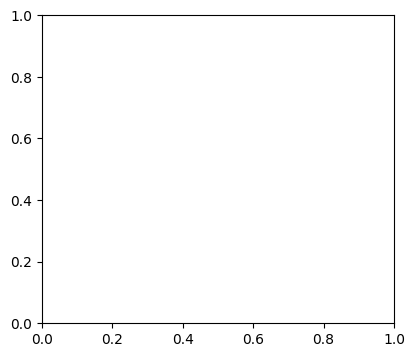

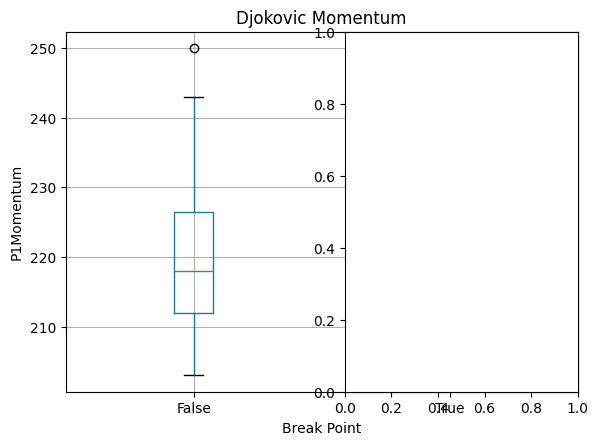

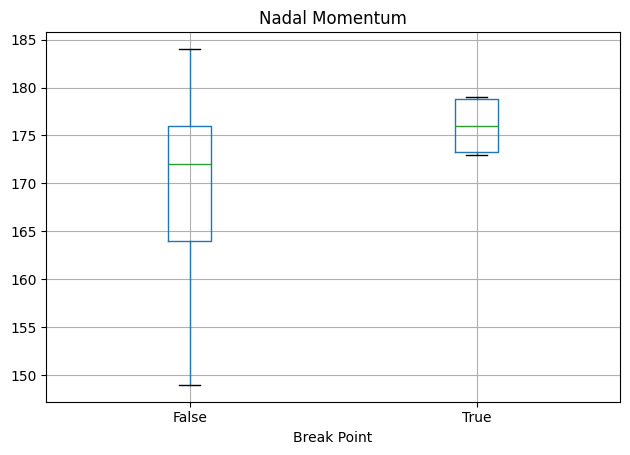

In [148]:
df5["is_break_point"] = (
    (df5["P1BreakPoint"] == 1) |
    (df5["P2BreakPoint"] == 1)
)

def bp_owner(row):
    if row["P1BreakPoint"] == 1:
        return "Djokovic_BP"
    if row["P2BreakPoint"] == 1:
        return "Nadal_BP"
    return "No_BP"

df5["bp_owner"] = df5.apply(bp_owner, axis=1)


# Core comparison table
df5.groupby("is_break_point")[["P1Momentum", "P2Momentum"]].mean()
df5.groupby("bp_owner")[["P1Momentum", "P2Momentum"]].mean()


import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df5.boxplot(column="P1Momentum", by="is_break_point")
plt.title("Djokovic Momentum")
plt.suptitle("")
plt.xlabel("Break Point")
plt.ylabel("P1Momentum")

plt.subplot(1,2,2)
df5.boxplot(column="P2Momentum", by="is_break_point")
plt.title("Nadal Momentum")
plt.suptitle("")
plt.xlabel("Break Point")

plt.tight_layout()
plt.show()

# Momentum by whose break point (very revealing)

# Draw court

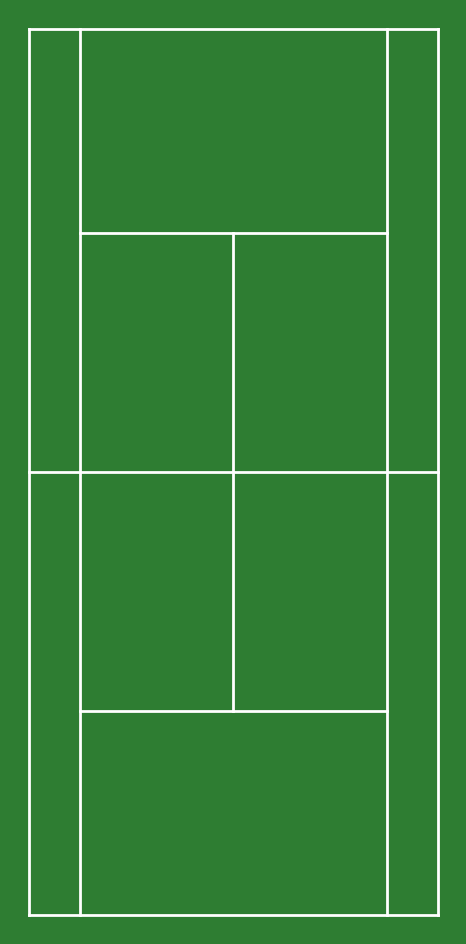

In [149]:
import matplotlib.pyplot as plt

def draw_tennis_court_green(ax=None, lw=2, court_color="#2e7d32"):
    """
    Draw a tennis court with green background and white lines.

    Parameters
    ----------
    ax : matplotlib.axes.Axes, optional
        Axes to draw the court on. If None, a new figure and axes are created.
    lw : float, optional
        Line width for court lines.
    court_color : str, optional
        Background color of the court (hex or named color).

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the tennis court drawn.
    """

    # Ensure no style interference
    plt.style.use("default")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 12))
    else:
        fig = ax.figure

    # Force background colors (important!)
    fig.patch.set_facecolor(court_color)
    ax.set_facecolor(court_color)

    # --- ITF court dimensions (meters) ---
    court_length = 23.77
    court_width = 10.97
    singles_width = 8.23
    service_line_dist = 6.40

    # --- Outer boundaries ---
    ax.plot([-court_width/2, court_width/2], [0, 0], lw=lw, color="white")
    ax.plot([-court_width/2, court_width/2], [court_length, court_length], lw=lw, color="white")
    ax.plot([-court_width/2, -court_width/2], [0, court_length], lw=lw, color="white")
    ax.plot([court_width/2, court_width/2], [0, court_length], lw=lw, color="white")

    # --- Singles sidelines ---
    ax.plot([-singles_width/2, -singles_width/2], [0, court_length], lw=lw, color="white")
    ax.plot([singles_width/2, singles_width/2], [0, court_length], lw=lw, color="white")

    # --- Net ---
    ax.plot([-court_width/2, court_width/2],
            [court_length/2, court_length/2],
            lw=lw, color="white")

    # --- Service lines ---
    ax.plot([-singles_width/2, singles_width/2],
            [court_length/2 + service_line_dist]*2,
            lw=lw, color="white")
    ax.plot([-singles_width/2, singles_width/2],
            [court_length/2 - service_line_dist]*2,
            lw=lw, color="white")

    # --- Center service line ---
    ax.plot([0, 0],
            [court_length/2 - service_line_dist,
             court_length/2 + service_line_dist],
            lw=lw, color="white")

    # --- Formatting ---
    ax.set_aspect("equal")
    ax.axis("off")

    ax.set_xlim(-court_width/2 - 0.5, court_width/2 + 0.5)
    ax.set_ylim(-0.5, court_length + 0.5)

    return ax


fig, ax = plt.subplots(figsize=(6, 12))
draw_tennis_court_green(ax)
plt.show()

## Plot serve

In [150]:
def extract_serve(cell):
    """
    Extract the serve code from an MCP cell.
    Returns an empty string if no serve is present.
    """
    if not isinstance(cell, str):
        return pd.NA

    cell = cell.strip()
    if not cell:
        return pd.NA

    for idx, char in enumerate(cell):
        if char.lower() in SHOT_LETTERS:
            return cell[:idx]   # everything before first rally shot

    # No rally shots → serve-only point (ace, double fault, etc.)
    return cell

df["1st_serve"] = df["1st"].apply(extract_serve)
df["2nd_serve"] = df["2nd"].apply(extract_serve)

### Serve percentage per player

In [151]:
df.groupby("PointServer")["2nd_serve"].apply(
    lambda s: s.isna().mean() * 100
)


PointServer
1    69.879518
2    70.935961
Name: 2nd_serve, dtype: float64

## First serve per player

In [152]:
first_serves = df[df["2nd_serve"].isna()].copy()

first_serves["serve_direction"] = pd.to_numeric(
    first_serves["1st_serve"].str[0],
    errors="coerce"
)

first_serves = first_serves[first_serves["serve_direction"].isin([4, 5, 6])]

direction_map = {4: "Wide", 5: "Body", 6: "T"}
first_serves["serve_direction_label"] = first_serves["serve_direction"].map(direction_map)


In [153]:
serve_dir_pct_by_player = (
    first_serves
    .groupby("PointServer")["serve_direction_label"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(1)
)

serve_dir_pct_by_player


serve_direction_label,Body,T,Wide
PointServer,,,
1,7.5,55.1,37.4
2,25.0,47.1,27.9


In [154]:
mean_speed_by_dir_player = (
    first_serves
    .groupby(["PointServer", "serve_direction_label"])["Speed_KMH"]
    .mean()
    .unstack()
    .round(1)
)

mean_speed_by_dir_player

serve_direction_label,Body,T,Wide
PointServer,,,
1,174.2,175.9,164.4
2,171.3,173.2,153.1


In [155]:
# Direction labels and x‑coordinates
first_serves = df[df["2nd_serve"].isna()].copy()

first_serves["serve_direction"] = pd.to_numeric(
    first_serves["1st_serve"].str[0],
    errors="coerce"
)

first_serves = first_serves[first_serves["serve_direction"].isin([4, 5, 6])]

direction_label_map = {4: "Wide", 5: "Body", 6: "T"}
first_serves["serve_direction_label"] = first_serves["serve_direction"].map(direction_map)


first_serves["serve_direction_label"] = (
    first_serves["serve_direction"].map(direction_label_map)
)

summary = (
    first_serves
    .groupby(["PointServer", "serve_direction_label"])
    .agg(
        count=("serve_direction_label", "size"),
        mean_speed=("Speed_KMH", "mean")
    )
)

summary["percentage"] = (
    summary["count"]
    / summary.groupby(level=0)["count"].transform("sum")
) * 100

summary = summary.reset_index()
summary["percentage"] = summary["percentage"].round(1)
summary["mean_speed"] = summary["mean_speed"].round(1)

In [156]:
def annotate_serve_zones(ax, summary_player):
    """
    Place text boxes for Wide / Body / T serve placements:
    - Just BEHIND the service line (toward the net)
    - Between singles sideline and center line
    - Larger font for direction label
    - Smaller font for percentage & speed
    """

    # Court constants (must match court drawing)
    court_length = 23.77
    net_y = court_length / 2
    service_line_y = net_y + 6.40
    doubles_half_width = 10.97 / 2

    # Horizontal centers (between singles sideline and center line)
    x_centers = {
        "Wide": -doubles_half_width,   # near singles sideline
        "Body": -doubles_half_width / 2.0,                           # center
        "T": 0.0         # near singles sideline
    }

    # Vertical position: just behind service line (toward net)
    y_title = service_line_y + 0.45   # label line
    y_stats = service_line_y - 0.45   # numbers line

    for _, row in summary_player.iterrows():
        x = x_centers[row["serve_direction_label"]]

        # --- Direction label (larger font) ---
        ax.text(
            x, y_title,
            row["serve_direction_label"],
            ha="center",
            va="bottom",
            fontsize=13,
            color="white",
            fontweight="bold",
            bbox=dict(facecolor="#4CAF50", alpha=0.65, pad=3),
            zorder=3
        )

        # --- Percentage + speed (smaller font) ---
        stats_text = f"{row['percentage']}%\n\n{row['mean_speed']}\nkm/h"

        ax.text(
            x, y_stats,
            stats_text,
            ha="center",
            va="top",
            fontsize=9,
            color="white",
            bbox=dict(facecolor="black", alpha=0.55, pad=2),
            zorder=3
        )

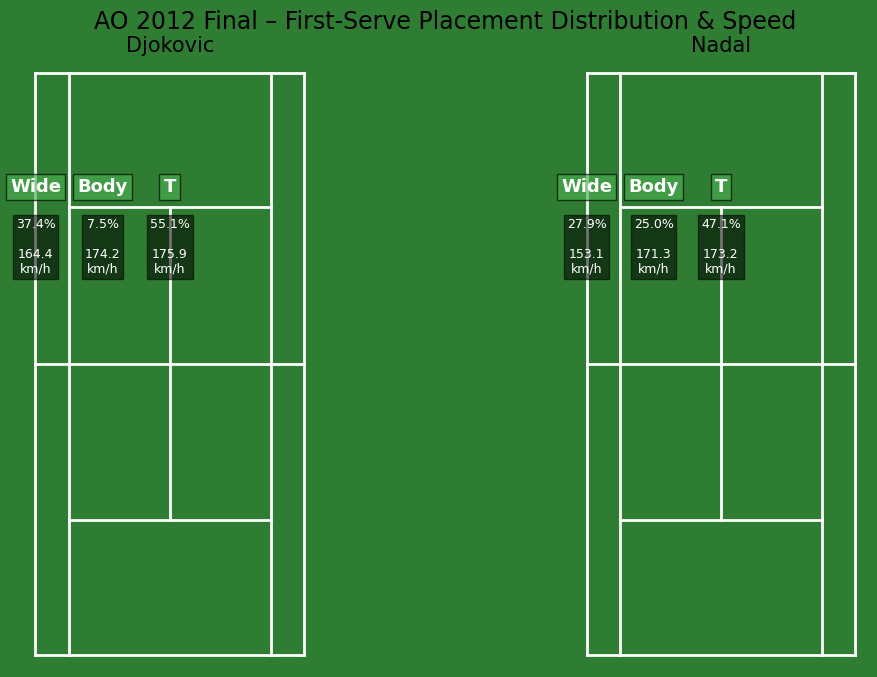

In [157]:
import matplotlib.pyplot as plt

players = {1: "Djokovic", 2: "Nadal"}

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

for ax, pid in zip(axes, [1, 2]):
    # Draw your existing green court
    draw_tennis_court_green(ax)

    # Subset summary for this player
    summary_p = summary[summary["PointServer"] == pid]

    # Annotate serve placement info
    annotate_serve_zones(ax, summary_p)

    ax.set_title(players[pid], fontsize=15)

fig.suptitle(
    "AO 2012 Final – First‑Serve Placement Distribution & Speed",
    fontsize=17,
    y=0.96
)

plt.tight_layout()
plt.show()

## Second serve per player

In [158]:
second_serves = df[df["2nd_serve"].notna()].copy()

## Returns

In [174]:
returns = shots[
    (shots["shotIndex"] == 0) &
    (shots["depth"].isin([7, 8, 9]))
].copy()

depth_map = {
    7: "Shallow",
    8: "Medium",
    9: "Deep"
}

returns["return_depth_label"] = returns["depth"].map(depth_map)

return_summary = (
    returns
    .groupby("hitter")["return_depth_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack()
)

return_summary


return_depth_label,Deep,Medium,Shallow
hitter,,,
Novak Djokovic,23.2,50.7,26.1
Rafael Nadal,21.3,32.8,45.9


In [185]:
def annotate_return_depth(ax, return_summary_player):
    """
    Place return depth (Shallow / Medium / Deep) text boxes on the court.
    """

    # Court constants
    court_length = 23.77
    net_y = court_length / 2
    service_line_y = net_y + 6.40

    y_positions = {
        "Shallow": service_line_y - 3.5,    # inside service box
        "Medium":  service_line_y - 0.8,    # mid‑court
        "Deep":    court_length - 1.6       # near baseline
    }


    for depth_label, pct in return_summary_player.items():
        ax.text(
            0,
            y_positions[depth_label],
            f"{depth_label}\n{pct}%",
            ha="center",
            va="center",
            fontsize=12,
            color="white",
            fontweight="bold",
            bbox=dict(
                facecolor="black",
                alpha=0.65,
                pad=4
            ),
            zorder=4
        )

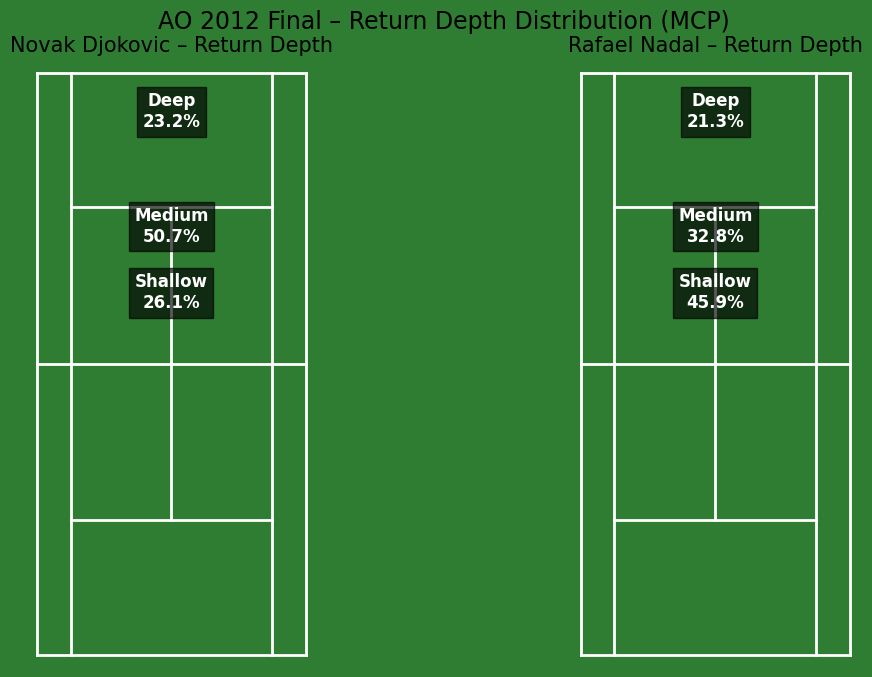

In [186]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

players = ["Novak Djokovic", "Rafael Nadal"]

for ax, player in zip(axes, players):
    draw_tennis_court_green(ax)

    annotate_return_depth(
        ax,
        return_summary.loc[player]
    )

    ax.set_title(f"{player} – Return Depth", fontsize=15)

fig.suptitle(
    "AO 2012 Final – Return Depth Distribution (MCP)",
    fontsize=17,
    y=0.96
)

plt.tight_layout()
plt.show()

# Verifying Tactics: Analysis
Let us verify if my perceived tactics of both players are correct.
1. Djokovic: "My backhand is better than yours."
    Djokovic's main tactic was to send a deep backhand down the line (from the ad-court) to Nadal's backhand (on the deuce-court).
2. Nadal: "My forehand is monstruous."
    Nadal, on the other hand, was trying to send his forhand inside-out crosscourt (from the deuce-court) onto Djokovic's backhand to create angles.

In [ ]:
# Type 1: Djokovic backhand down the line -> Nadal answer
djoko_bh_dtl = shots[(shots.hitter == "Novak Djokovic") &
                     (shots.stroke == "b") &
                     (shots.direction == 1)].copy()
djoko_bh_dtl["nextIndex"] = djoko_bh_dtl["shotIndex"] + 1

djokoTactic = djoko_bh_dtl.merge(
    shots[["Pt", "shotIndex", "target_zone", "stroke", "direction"]],
    left_on=["Pt", "nextIndex"],
    right_on=["Pt", "shotIndex"],
    suffixes=("_djoko", "_nadal")
).drop(columns="nextIndex")

djokoTactic

,Pt,shotIndex_djoko,server,hitter,stroke_djoko,positions,direction_djoko,errorCode,outcome,targetZone_djoko,shotIndex_nadal,targetZone_nadal,stroke_nadal,direction_nadal
0,5,1,Novak Djokovic,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,2,to opponent BH,b,3
1,11,9,Novak Djokovic,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,10,to opponent BH,s,3
2,19,0,Rafael Nadal,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,1,middle,f,2
3,19,12,Rafael Nadal,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,13,to opponent BH,s,3
4,23,3,Novak Djokovic,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,4,to opponent BH,s,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,354,10,Rafael Nadal,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,11,to opponent FH,b,1
91,362,1,Novak Djokovic,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,2,to opponent FH,b,1
92,362,15,Novak Djokovic,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,16,middle,b,2
93,365,3,Novak Djokovic,Novak Djokovic,b,NaN,1,NaN,NaN,to opponent BH,4,middle,s,2


In [24]:
djokoTactic["prevIndex"] = djokoTactic["shotIndex_djoko"] - 1
djokoTactic = djokoTactic.merge(
    shots[["Pt", "shotIndex", "targetZone"]],
    left_on=["Pt", "prevIndex"],
    right_on=["Pt", "shotIndex"],
    how="left",
    suffixes=("", "_prev")
).drop(columns=["prevIndex", "shotIndex"]).rename(columns={"targetZone": "targetZone_nadal_prev"})

fixed = ["stroke_djoko", "direction_djoko", "stroke_nadal", "direction_nadal", "targetZone_nadal_prev", "targetZone_djoko", "targetZone_nadal"]
rest = [col for col in djokoTactic.columns if col not in fixed]
# rest is now [X, Y]
djokoTactic = djokoTactic[rest + fixed]

djokoTactic

,Pt,shotIndex_djoko,server,hitter,positions,errorCode,outcome,shotIndex_nadal,stroke_djoko,direction_djoko,stroke_nadal,direction_nadal,targetZone_nadal_prev,targetZone_nadal_prev,targetZone_djoko,targetZone_nadal
0,5,1,Novak Djokovic,Novak Djokovic,NaN,NaN,NaN,2,b,1,b,3,to opponent BH,to opponent BH,to opponent BH,to opponent BH
1,11,9,Novak Djokovic,Novak Djokovic,NaN,NaN,NaN,10,b,1,s,3,to opponent BH,to opponent BH,to opponent BH,to opponent BH
2,19,0,Rafael Nadal,Novak Djokovic,NaN,NaN,NaN,1,b,1,f,2,NaN,NaN,to opponent BH,middle
3,19,12,Rafael Nadal,Novak Djokovic,NaN,NaN,NaN,13,b,1,s,3,middle,middle,to opponent BH,to opponent BH
4,23,3,Novak Djokovic,Novak Djokovic,NaN,NaN,NaN,4,b,1,s,3,middle,middle,to opponent BH,to opponent BH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,354,10,Rafael Nadal,Novak Djokovic,NaN,NaN,NaN,11,b,1,b,1,middle,middle,to opponent BH,to opponent FH
91,362,1,Novak Djokovic,Novak Djokovic,NaN,NaN,NaN,2,b,1,b,1,middle,middle,to opponent BH,to opponent FH
92,362,15,Novak Djokovic,Novak Djokovic,NaN,NaN,NaN,16,b,1,b,2,middle,middle,to opponent BH,middle
93,365,3,Novak Djokovic,Novak Djokovic,NaN,NaN,NaN,4,b,1,s,2,to opponent BH,to opponent BH,to opponent BH,middle


In [31]:
djokoTactic["stroke_nadal"].value_counts()

stroke_nadal
s    43
b    37
f     4
d     4
n     3
w     3
r     1
Name: count, dtype: int64

In [34]:
djokoNadalSlice = djokoTactic[djokoTactic["stroke_nadal"] == 's']
djokoNadalBH = djokoTactic[djokoTactic["stroke_nadal"] == 'b']
djokoNadalRest = djokoTactic[~djokoTactic["stroke_nadal"].isin(['s', 'b'])]

print(df[df.index.isin(djokoNadalSlice['Pt'].unique())][["PtWinner"]].value_counts())
print(df[df.index.isin(djokoNadalBH['Pt'].unique())][["PtWinner"]].value_counts())
print(df[df.index.isin(djokoNadalRest['Pt'].unique())][["PtWinner"]].value_counts())

PtWinner
1           21
2           17
Name: count, dtype: int64
PtWinner
1           19
2           16
Name: count, dtype: int64
PtWinner
2           13
1            2
Name: count, dtype: int64


In [21]:
djokoBHDtlPoints = df[df.index.isin(djokoTactic['Pt'].unique())][["PtWinner"]]
djokoBHDtlPoints["PtWinner"].value_counts()

PtWinner
1    38
2    37
Name: count, dtype: int64

In [9]:
# Type 1: Djokovic backhand down the line -> Nadal answer
djoko_bh_dtl = shots[(shots.hitter == "Novak Djokovic") &
                     (shots.stroke == "b") &
                     (shots.direction == 1)].copy()
djoko_bh_dtl["prevIndex"] = djoko_bh_dtl["shotIndex"] - 1
djoko_bh_dtl["nextIndex"] = djoko_bh_dtl["shotIndex"] + 1

responses_type1 = djoko_bh_dtl.merge(
    shots,
    left_on=["Pt", "nextIndex"],
    right_on=["Pt", "shotIndex"],
    suffixes=("_djoko", "_nadal")
)
responses_type1 = responses_type1[responses_type1["hitter"] == "Rafael Nadal"]

# Nadal’s reply direction & court position
resp_dir_counts = responses_type1["targetZone_nadal"].value_counts()
resp_position_counts = responses_type1["positions_nadal"].value_counts()
pts_type1 = sorted(responses_type1["Pt"].unique())


# Djokovic backhand down the line -> Nadal response
resp_dir_counts = (
    responses_type1["targetZone_nadal"]
    .value_counts(dropna=False)
    .rename_axis("direction")
    .to_frame("count")
)
resp_dir_counts["pct"] = resp_dir_counts["count"] / resp_dir_counts["count"].sum() * 100

KeyError: 'hitter'